Dataset Characteristics

In [ ]:
import numpy as np
import pandas as pd
import json

from sklearn.metrics import average_precision_score, brier_score_loss, confusion_matrix, log_loss, roc_auc_score

with open("info.json", "r") as file:
    info = json.load(file)

df = pd.read_csv("dataset.txt", sep='\t')
# df = df[df['id'].isin(info['id'])]

display(df.describe())
display(df['label'].value_counts())


def get_binary_metrics(y_true, y_prob, y_pred=None, threshold=None, metric=None):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    if threshold is not None:
        y_pred = np.where(y_prob >= threshold, 1, 0)
    elif y_pred is not None:
        y_pred = np.array(y_pred)
    else:
        raise ValueError("y_pred and threshold are both None. One must be provided.")

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        "logloss": log_loss(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "rocauc": roc_auc_score(y_true, y_prob),
        "averageprecision": average_precision_score(y_true, y_prob),
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
        "n": int(tn + fp + fn + tp),
        "sensitivity": tp / (tp + fn) if tp + fn > 0 else 0.0,
        "specificity": tn / (tn + fp) if tn + fp > 0 else 0.0,
        "accuracy": (tp + tn) / (tn + fp + fn + tp),
        "precision": tp / (tp + fp) if tp + fp > 0 else 0.0,
        "npv": tn / (tn + fn) if tn + fn > 0 else 0.0,
        "nnr": (tp + fp) / tp if tp > 0 else 0.0,
        "f1": (2.0 * tp) / ((2.0 * tp) + fp + fn) if tp + fp + fn > 0 else 0.0,
        "f2": (5.0 * tp) / ((5.0 * tp) + (4.0 * fn) + fp) if tp + fp + fn > 0 else 0.0,
        "mcc": (
            ((tp * tn) - (fp * fn))
            / math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
            if (tp + fp > 0 and tp + fn > 0 and tn + fp > 0 and tn + fn > 0)
            else 0.0
        ),
        "wsos": ((tn + fn) / (tn + fp + fn + tp))
        - (1 - (tp / (tp + fn) if tp + fn > 0 else 0.0)),
        "youden": (tp / (tp + fn) if tp + fn > 0 else 0.0)
        + (tn / (tn + fp) if tn + fp > 0 else 0.0)
        - 1,
    }

    if metric is None:
        return metrics
    elif isinstance(metric, list):
        return {m: metrics[m] for m in metric if m in metrics}
    else:
        return metrics[metric]



metrics = get_binary_metrics(y_true=df['label'], y_prob=df['probability'], threshold=0.5)

for m in metrics:
    print(m, metrics[m])

,index,id,label,probability,logit_pos,logit_neg
count,60802.000000,6.080200e+04,60802.000000,60802.000000,60802.000000,60802.000000
mean,30400.500000,2.572215e+07,0.560672,0.599029,-0.036322,-0.216239
std,17552.169871,8.168922e+06,0.496309,0.399125,1.776434,1.895555
min,0.000000,1.060106e+07,0.000000,0.000773,-3.536476,-2.485914
25%,15200.250000,1.906415e+07,0.000000,0.127366,-1.092875,-1.731837
50%,30400.500000,2.830270e+07,1.000000,0.816476,0.537497,-0.955671
75%,45600.750000,3.215015e+07,1.000000,0.958442,1.406725,0.840332
max,60801.000000,3.883910e+07,1.000000,0.992208,2.419996,3.681037


label
1    34090
0    26712
Name: count, dtype: int64

NameError: name 'utils' is not defined

### Bar charts
Get the bar graphs for the top 15 most important positive and negative features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80901 entries, 0 to 80900
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            80901 non-null  int64  
 1   id                    80901 non-null  int64  
 2   dataset               80901 non-null  object 
 3   sv_value              80901 non-null  float64
 4   sv_token              80899 non-null  object 
 5   sv_base_value         80901 non-null  float64
 6   ig_value              80901 non-null  float64
 7   ig_token              80897 non-null  object 
 8   ig_base_value         80901 non-null  float64
 9   gpt_index_value       80897 non-null  float64
 10  gpt_index_word_value  80848 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 6.8+ MB


None

N features: 80901
N unique features: 6369
0
6369
There are 6369 unique tokens that occurred 1+ times.
80901 tokens remain.


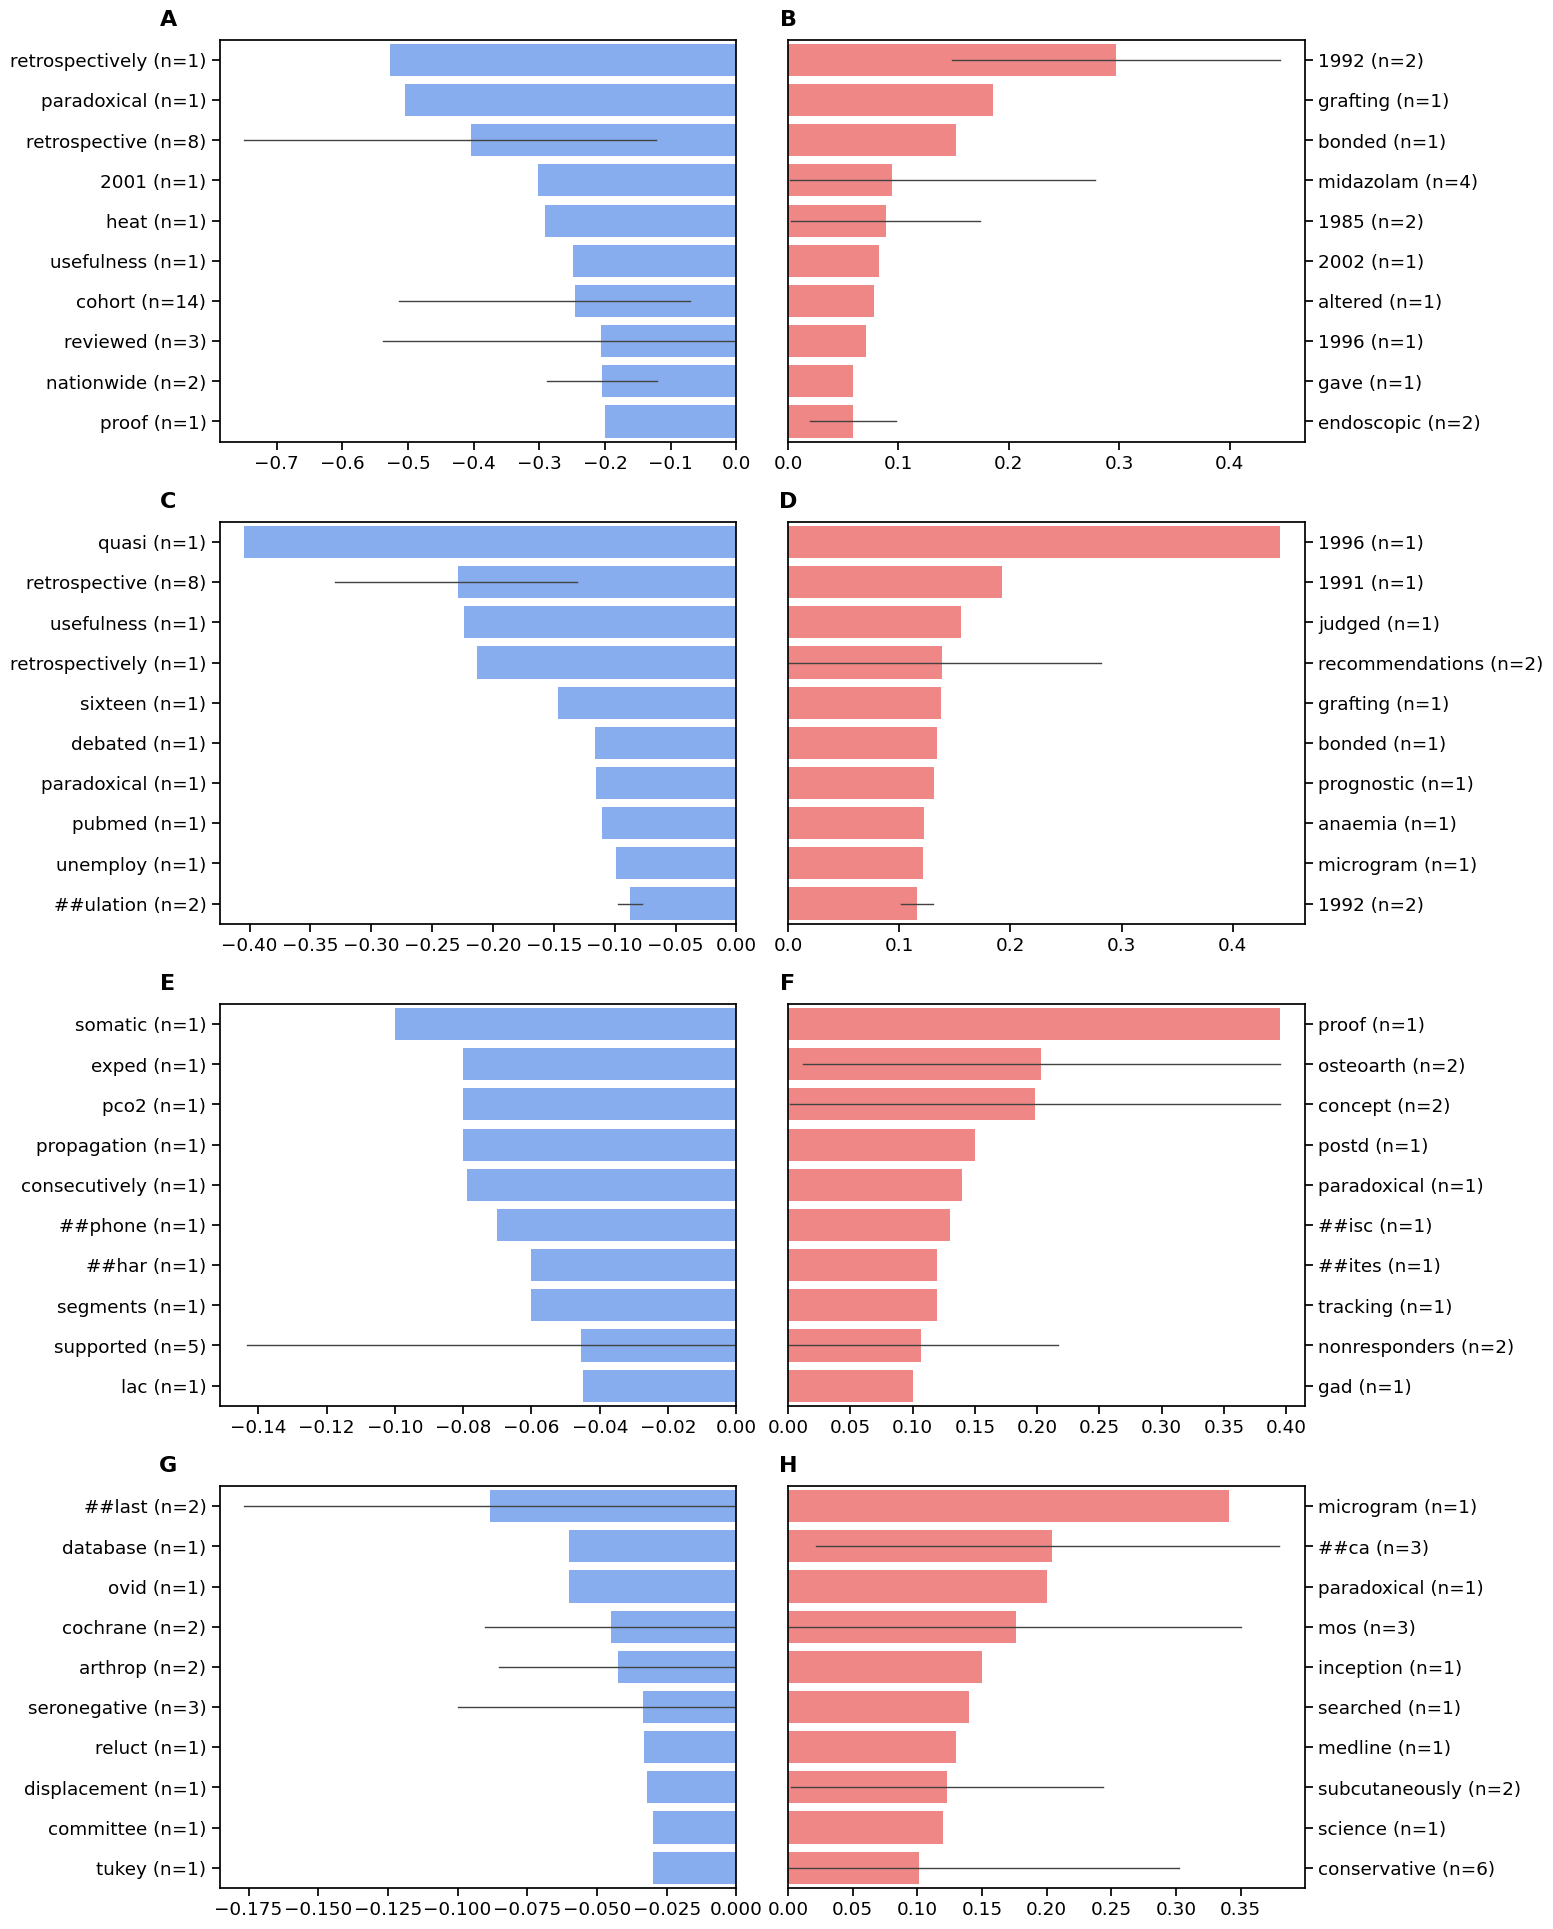

There are 1073 unique tokens that occurred 10+ times.
66391 tokens remain.


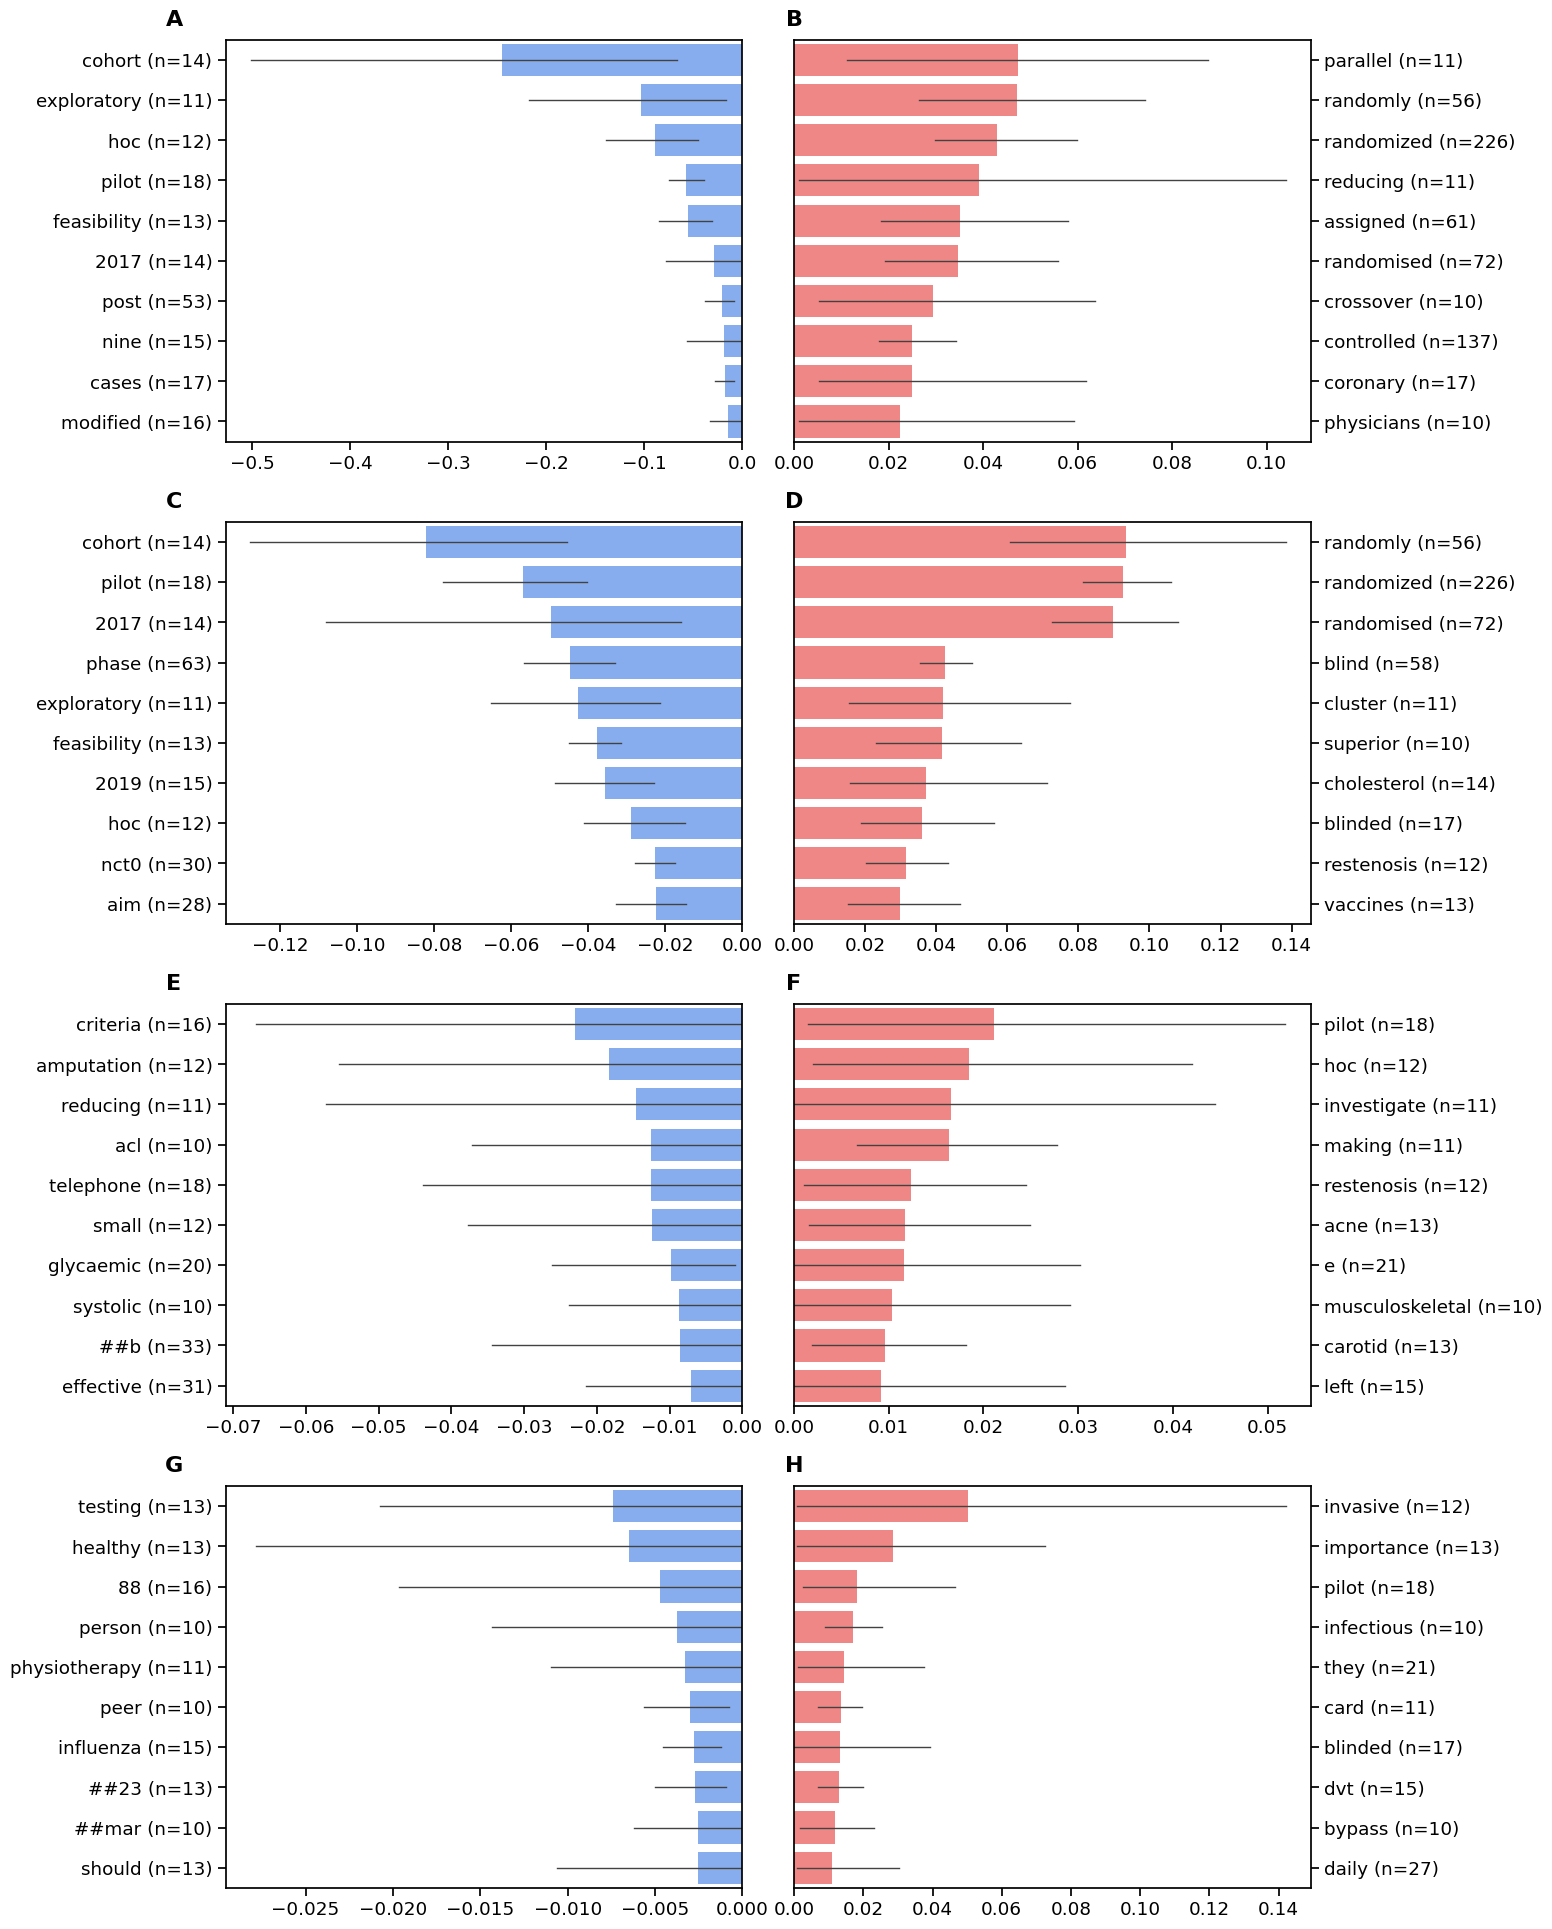

There are 87 unique tokens that occurred 100+ times.
41418 tokens remain.


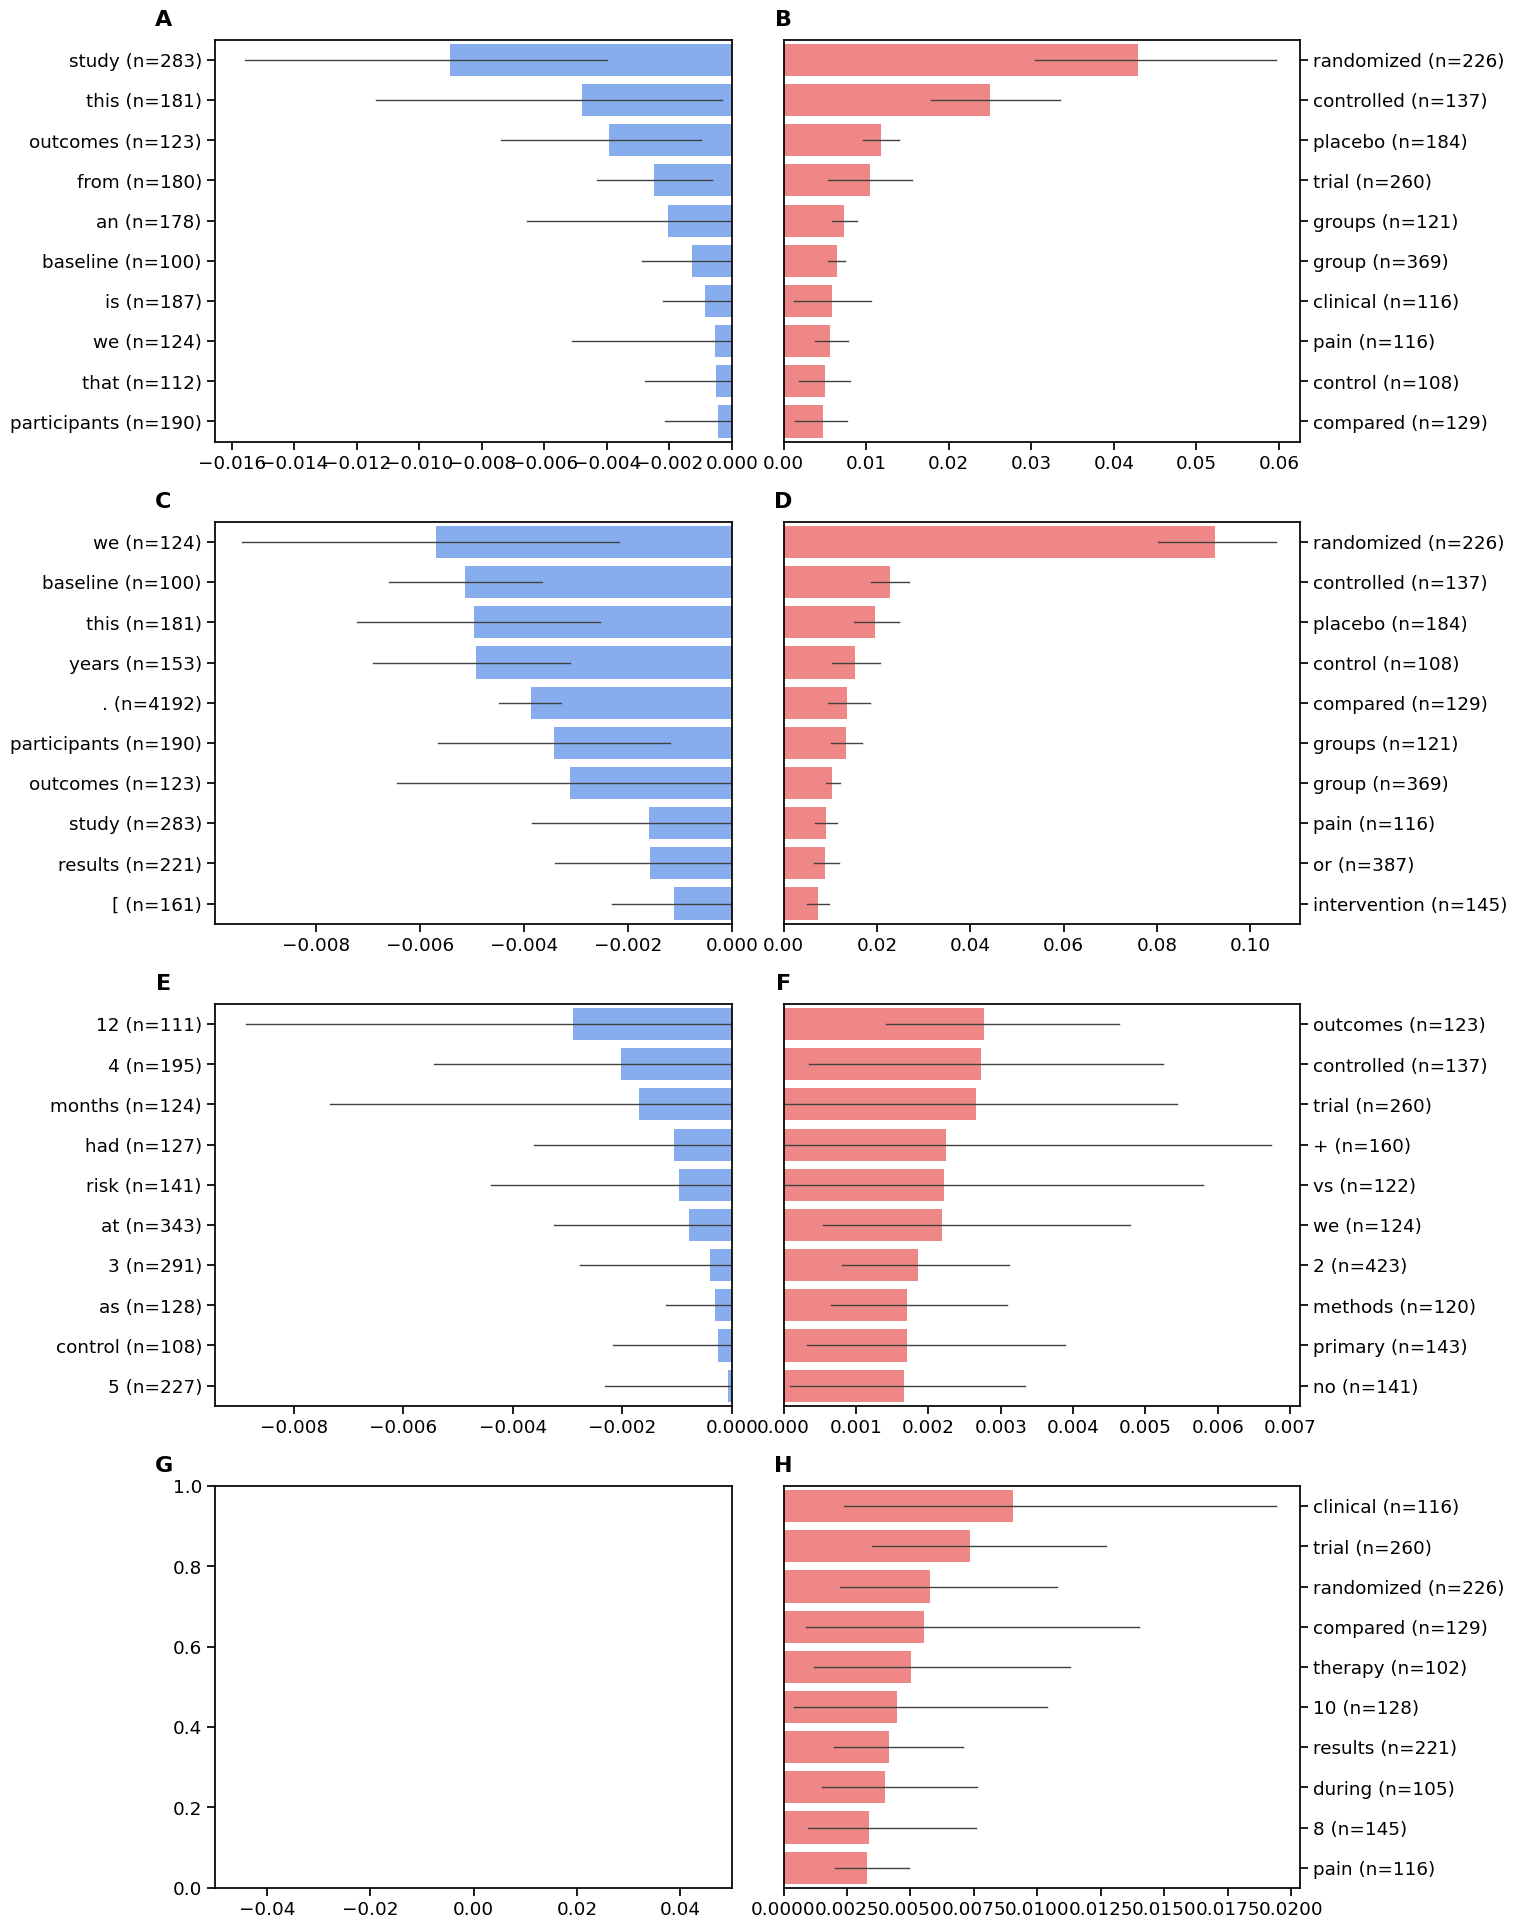

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

path = Path("results")

df = pd.read_csv(path / "200_feature_attributions.csv", dtype={"ig_token": str})
NUM_TOP_FEATURES = 10

display(df.info())

df['ig_token'] = df['ig_token'].fillna("[EMPTY]")

explainer_result_cols = ['sv_value', 'ig_value', 'gpt_index_value', 'gpt_index_word_value']

tokens = df['ig_token']
token_counts = tokens.value_counts()

print(f"N features: {len(tokens)}")
print(f"N unique features: {len(tokens.unique())}")
print(df['ig_token'].isna().sum())

print(len(token_counts))

sns.set_context("notebook", font_scale=1.2)
for occurance in [1, 10, 100]:
    df_occurance = df[tokens.isin(token_counts[token_counts >= occurance].index)]
    print(f"There are {len(token_counts[token_counts >= occurance])} unique tokens that occurred {occurance}+ times.")
    print(f"{len(df_occurance)} tokens remain.")
    
    labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
    
    fig, axes = plt.subplots(4, 2, figsize=(14, 24), sharey=False, gridspec_kw={'wspace': 0.1})
    axes = axes.flatten()
    
    columns_and_features = [(col, ascending) for col in explainer_result_cols for ascending in [True, False]]

    
    for i, cf in enumerate(columns_and_features):
        col, ascending = cf
        df_occurance_unique_tokens = df_occurance.groupby('ig_token')[col]
        # print(occurance, col)

        # Create a single figure with two subplots
        # Create a figure with two side-by-side plots
        # fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False, gridspec_kw={'wspace': 0.1})  # Adjust spacing

        # labels = ['A', 'B']  # Labels for subplots
        positions = [(-0.1, 1.05), (0, 1.05)]  # Positions for labels (left for first, right for second)

        
        # Calculate median and absolute median for sorting
        unique_tokens_sorted = df_occurance_unique_tokens.mean().sort_values(ascending=ascending)

        # Keep only negative or positive features accordingly
        if ascending:
            unique_tokens_sorted = unique_tokens_sorted[unique_tokens_sorted < 0]  # Negative features
        else:
            unique_tokens_sorted = unique_tokens_sorted[unique_tokens_sorted > 0]  # Positive features

        # Select top 10 features
        top_unique_tokens = unique_tokens_sorted.head(NUM_TOP_FEATURES).index

        # Filter data for top 10 features
        df_occurance_top_tokens = df_occurance[df_occurance['ig_token'].isin(top_unique_tokens)]
        sample_sizes = df_occurance_top_tokens.groupby('ig_token')[col].count()

        # Create label with sample size
        df_occurance_top_tokens['tokens_with_sample_size'] = df_occurance_top_tokens['ig_token'].apply(
            lambda x: f"{x} (n={sample_sizes[x]})"
        )

        # Sort values for plotting
        df_occurance_unique_top_tokens = df_occurance_top_tokens.groupby('ig_token')[col]
        stats = df_occurance_unique_top_tokens.mean().sort_values(ascending=ascending)

        # Define colors
        colors = ['#ff7675' if val > 0 else '#76A9FF' for val in stats]
        order = [f"{tokens} (n={sample_sizes[tokens]})" for tokens in stats.index]

        # Plot
        sns.barplot(
            data=df_occurance_top_tokens,
            x=col,
            y='tokens_with_sample_size',
            palette=colors,
            orient='h',
            order=order,
            ax=axes[i],
            err_kws={'linewidth': 1}
        )

        # Formatting
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

        # Adjust x-axis limits
        if ascending:  # Negative values: Ensure x-axis ends at 0
            axes[i].set_xlim(None, 0)
            axes[i].yaxis.tick_left()
        else:  # Positive values: Ensure x-axis starts at 0
            axes[i].set_xlim(0, None)
            axes[i].yaxis.tick_right()

        # Add labels 'A' and 'B' at the top-left of each subplot
        axes[i].text(positions[i % 2][0], positions[i % 2][1], labels[i], transform=axes[i].transAxes,
                        fontsize=16, fontweight='bold', va='center', ha='center')
        

    # # Adjustments to move y-axis labels (feature names) to the right on the positive figure
    # axes[0].yaxis.tick_left()  # Keep y-axis labels on the left for negative features
    # axes[1].yaxis.tick_right()  # Move y-axis labels to the right for positive features

    plt.tight_layout()
    for format in ['png', 'svg']:
        save_path = Path("results") / "feature_importance_figures_large_text"
        save_path.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path / f"{occurance}.{format}", bbox_inches='tight')
    plt.show()

# Regression

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, spearmanr, pearsonr, wasserstein_distance
from sklearn.linear_model import LinearRegression
import itertools
import seaborn as sns
import os

path = Path("results")
df = pd.read_csv(os.path.join('results', '200_feature_attributions.csv'))


def analyze(a, b):
    x = df[a]
    y = df[b]

    # Calculate Pearson correlation
    correlation, p_value = pearsonr(x, y)
    print(f"Pearson correlation between {a} and {b}: {correlation:.3f}, P-value: {p_value:.3f}")
    
    # Calculate Spearman correlation
    correlation, p_value = spearmanr(x, y)
    print(f"Spearman correlation between {a} and {b}: {correlation:.3f}, P-value: {p_value:.3f}")
    
    # Calculate Kendall's Tau
    tau, p_value = kendalltau(x, y)
    print(f"Kendall's Tau between {a} and {b}: {tau:.3f}, P-value: {p_value:.3f}")
    
    # Calculate Wasserstein distance
    distance = wasserstein_distance(x, y)
    print(f"Wasserstein Distance between {a} and {b}: {distance:.3f}")



cols_mapping = {
    'sv_value': "SHAP", 
    'ig_value': "IG",
    'gpt_index_value': "GPT-index",
    'gpt_index_word_value': "GPT-token",
}

pairs = list(itertools.combinations(cols_mapping.keys(), 2))

with open("info.json", "r") as f:
    info = json.load(f)

df_plot = df[['dataset', 'sv_value', 'ig_value', 'gpt_index_value', 'gpt_index_word_value']]
df_plot.rename(columns=cols_mapping, inplace=True)
display(df_plot.head())

# sns.pairplot(df_plot, hue='dataset')

fig, axes = plt.subplots(3, 2, figsize=(12, 18), sharey=False, gridspec_kw={'wspace': 0.2},)
axes = axes.flatten()
panel_labels = ['A', 'B', 'C', 'D', 'E', 'F']

for i, pair in enumerate(pairs):
    a, b = pair
    df[a].fillna(0, inplace=True)
    df[b].fillna(0, inplace=True)

    analyze(a, b)
    
    # Scatter plot
    sns.scatterplot(x=df[a], y=df[b], s=10, alpha=0.7, ax=axes[i])

    axes[i].set_xlabel(cols_mapping[a])
    axes[i].set_ylabel(cols_mapping[b])
    axes[i].grid(True)
    # axes[i].text(-0.1, 1.05, labels[i], transform=axes[i].transAxes,
    #              fontsize=12, fontweight='bold', va='center', ha='center')
for format in ['pdf', 'tif', 'svg']:
    plt.savefig(os.path.join("results", "feature_importance_figures", f"regression.{format}"), bbox_inches='tight')
# plt.savefig(os.path.join("feature_importance_figures", f"regression.svg"), bbox_inches='tight')
plt.show()

# Area over the perturbation curve

## Get AOPCs for each article from feature attributions

In [ ]:
from tqdm import tqdm
import json
import pandas as pd
import numpy as np
import warnings
import workers

warnings.filterwarnings('ignore')
path = Path("results")
df_fa = pd.read_csv(path / "200_feature_attributions.csv")
dfs_by_id = {key: value for key, value in df_fa.groupby("id")}
cols = ["ig_value", "sv_value", "gpt_index_value", "gpt_index_word_value"]

with open ("info.json", "r") as file:
    info = json.load(file)

output = []

# for each instance
for id in tqdm(info['id']):
    output.append({
        'id': id
    })

    # for each explainer
    for col in cols:
        # print(col)
        aopc_pos_list, _, aopc_neg_list, _ = workers.compute_aopc_separate(
            (id, dfs_by_id[id], col)
        )
        # these should have the same length as the number of tokens
        # the first value represent 0 tokens masked, the second represent 1 token masked, and so on
        aopc_pos = np.mean(aopc_pos_list)
        aopc_neg = np.mean(aopc_neg_list)
        aopc_both = np.mean(aopc_pos_list + aopc_neg_list)
        output[-1][f"aopc_{col}"] = aopc_both
        output[-1][f"aopc_pos_{col}"] = aopc_pos
        output[-1][f"aopc_neg_{col}"] = aopc_neg

df_output = pd.DataFrame(output)
display(df_output.head())
df_output.to_csv(os.path.join('results', "200_aopc.csv"), index=False)

## Process AOPCs

In [ ]:
from tqdm import tqdm
import json
import pandas as pd

import scipy.stats as stats
import numpy as np

cols_mapping = {
    'sv_value': "SHAP",
    'ig_value': "IG",
    'gpt_index_value': "GPT-index",
    'gpt_index_word_value': "GPT-token",
}
path = Path("results")
df = pd.read_csv(path / "200_aopc.csv")


def mean_ci(series, confidence=0.95):
    series = series.dropna()  # Remove NaN values
    if len(series) == 0:  # If empty after dropping NaNs, return "NaN"
        return "NaN (NaN, NaN)"

    mean = np.mean(series)

    if len(series) == 1:  # If only one value, no confidence interval can be calculated
        return f"{mean:.3f}"

    sem = stats.sem(series)  # Standard error of the mean
    ci_range = sem * stats.t.ppf((1 + confidence) / 2., len(series) - 1)
    lower = mean - ci_range
    upper = mean + ci_range

    return f"{mean:.3f} ({lower:.3f}, {upper:.3f})"


output = []

for explainer in cols_mapping.keys():
    output.append({
        "Explainer": cols_mapping[explainer],
        "AOPC": mean_ci(df[f'aopc_{explainer}']),
        "AOPC (Positive Tokens)": mean_ci(df[f'aopc_pos_{explainer}']),
        "AOPC (Negative Tokens)": mean_ci(df[f'aopc_neg_{explainer}']),
    })


df_output = pd.DataFrame(output)
df_output.to_csv(os.path.join('results' 'aopc_results.csv'), index=False)
display(df_output)

#### AOPC Curves

Calculate the pc values per token to generate the curves

In [ ]:
# def main(start_index: int, num=1000):
from tqdm import tqdm
import json
from pathlib import Path
import workers 
import warnings
import pandas as pd
import os
warnings.filterwarnings('ignore')

path = Path("results")
df_results = pd.read_csv(path / "200_feature_attributions.csv")
dfs_by_id = {key: value for key, value in df_results.groupby("id")}
cols = ["ig_value", "sv_value", "gpt_index_value", "gpt_index_word_value"]

# end_index = min(start_index+num, len(dfs_by_id))

# os.makedirs(os.path.join('results', 'aopc_individual_all_instances', f'{start_index}_{end_index-1}'), exist_ok=True)
save_path = Path(os.path.join('results', '200_pc_per_token'))
save_path.mkdir(parents=True, exist_ok=True)
# print("Indexes:")
# print(start_index, end_index-1)
ids = list(sorted(dfs_by_id.keys()))

output = []

# for each instance
for id in tqdm(ids):
    output.append({
        'id': id
    })

    # for each explainer
    for col in cols:
        # print(col)
        pc_pos, tokens_pos, pc_neg, tokens_neg = workers.compute_aopc_separate((id, dfs_by_id[id], col))
        df_temp = pd.DataFrame({
            'index': list(range(len(pc_pos))),
            'token': tokens_pos,
            'pc_value': pc_pos
        })
        df_temp.to_csv(save_path / f'{id}_{col}_pos.csv', index=False)
        
        df_temp = pd.DataFrame({
            'index': list(range(len(pc_neg))),
            'token': tokens_neg,
            'pc_value': pc_neg
        })
        df_temp.to_csv(save_path / f'{id}_{col}_neg.csv', index=False)

W0214 19:52:18.423000 22144 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
100%|██████████| 200/200 [54:30<00:00, 16.35s/it]


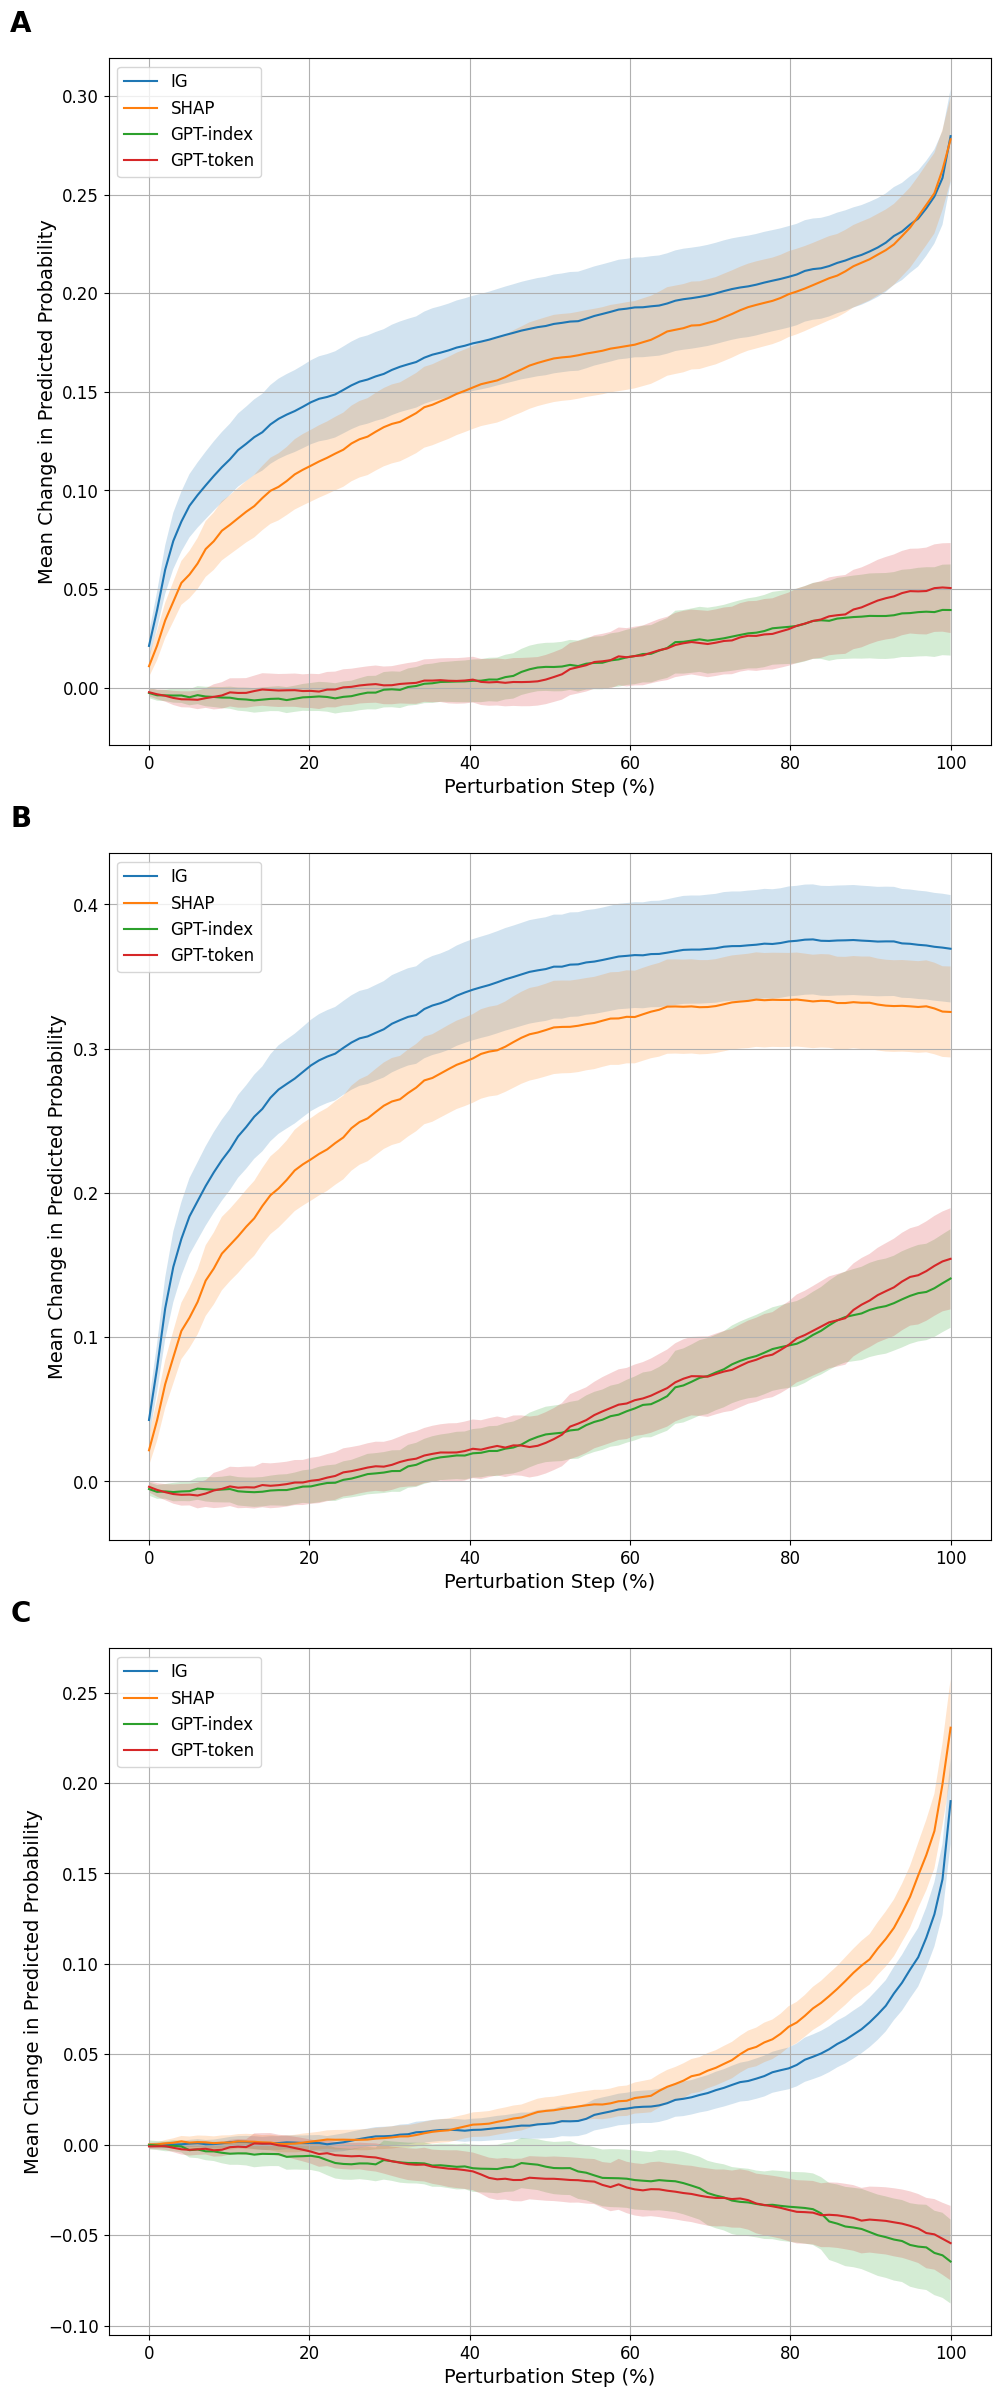

In [ ]:
from tqdm import tqdm
import json
import pandas as pd

from scipy.stats import norm
import numpy as np
import workers
import matplotlib.pyplot as plt
from pathlib import Path

spacing = np.linspace(0, 1, 100)
# df = pd.read_csv(os.path.join('results', 'stratified_results.csv'))
file_path = Path("results") / "200_pc_per_token"

def get_aopc_curve_values(file: str):
    spacing = np.linspace(0, 1, 100)

    df_aopc = pd.read_csv(file)
    df_aopc['step_percent'] = (df_aopc['index'] + 1) / len(df_aopc)

    try:
        interpolated = np.interp(spacing, df_aopc['step_percent'], df_aopc['pc_value'])
    except Exception as e:
        return None, file
    return interpolated, file

# dfs_by_id = {key: value for key, value in df_results.groupby("id")}
# cols = ["ig_value", "sv_value", "gpt_index_value", "gpt_index_word_value"]
cols = {
    "ig_value": "IG",
    "sv_value": "SHAP",
    "gpt_index_value": "GPT-index",
    "gpt_index_word_value": "GPT-token",
}
# df = df[cols]

fig, axes = plt.subplots(3, 1, figsize=(10, 24))
for i, sign in enumerate(["all", "pos", "neg"]): # need 3 figures

    for col in cols:
        # need one curve per col in each figure
        files = (
            list(file_path.glob(f"*{col}_{sign}.csv"))
            if sign != "all"
            else list(file_path.glob(f"*{col}*.csv"))
        )
        # print(files)
        dfs = [pd.read_csv(file) for file in files]

        apocs = []

        for d in dfs:
            if len(d) == 0:
                continue
            d['step_percent'] = (np.arange(len(d)) + 1) / len(d)
            interpolated = np.interp(spacing, d['step_percent'].astype(float), d['pc_value'].astype(float))
            apocs.append(interpolated)
        # print(dfs_interpolated)
        # print(df_interpolated.head())
        # print(curve)
        mean_curve = np.array(apocs).mean(axis=0)
        std_curve = np.array(apocs).std(axis=0)
        n = len(apocs)
        z = norm.ppf(0.975)  # 95% CI
        ci_margin = z * std_curve / np.sqrt(n)

        axes[i].plot(spacing*100, mean_curve, label=f'{cols[col]}')
        axes[i].fill_between(spacing*100, mean_curve - ci_margin, mean_curve + ci_margin, alpha=0.2)
        
    axes[i].set_xlabel('Perturbation Step (%)', fontsize=14)
    axes[i].set_ylabel('Mean Change in Predicted Probability', fontsize=14)
    axes[i].tick_params(axis='both', which='major', labelsize=12)
    axes[i].legend(fontsize=12)
    axes[i].grid(True)
    axes[i].text(-0.1, 1.05, ['A', 'B', 'C'][i], transform=axes[i].transAxes,
                 fontsize=20, fontweight='bold', va='center', ha='center')
plt.tight_layout()
plt.savefig("200_apoc_curves.svg", bbox_inches='tight')
plt.savefig("200_apoc_curves.tiff", dpi=300, bbox_inches='tight')
plt.savefig("200_apoc_curves.png", dpi=300, bbox_inches="tight")
plt.savefig("200_apoc_curves.pdf", bbox_inches="tight")
plt.show()

Compute baseline probability of model

In [5]:
import copy
import csv
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import shap
import torch
from tqdm import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

device = torch.device("cuda")
tokenizer = AutoTokenizer.from_pretrained("model", model_max_length=512, padding='max_length', truncation=True)
model = AutoModelForSequenceClassification.from_pretrained("model")

classifier = pipeline(
    'text-classification',
    model=model,
    tokenizer=tokenizer,
    device=device,
    top_k=None,
    truncation=True,
    padding='max_length',
    max_length=512,
)

classifier("")

Device set to use cuda


[[{'label': '0', 'score': 0.8832711577415466},
  {'label': '1', 'score': 0.11672885715961456}]]